
---
date: "2026-08-15"
date-modified: last-modified
format:
  html:
    toc: true
---


# Polyhedra, Polytopes, and Representation Complexity

In mathematical optimization and [linear programming](linear-programs.ipynb), the geometric domain over which optimization takes place is called a **polyhedron**. Understanding the duality between the constraint-based definition (halfspaces) and the generator-based definition (vertices) is critical for algorithm design, complexity theory, and computational geometry.

In this node, we formalize **polyhedra**, **polytopes**, the **Minkowski-Weyl Equivalence Theorem**, and analyze the representation complexity of canonical geometric families: the **Hypercube**, the **Cross-Polytope**, and the **Simplex**.

## 1\. Polyhedra and Polytopes (H-Representation)

::: {#def-polyhedron}
## Polyhedron (H-Representation)
A **polyhedron** $P \subseteq \mathbb{R}^n$ is the intersection of a finite number of [closed halfspaces](hyperplane-separation-theorems.ipynb#def-halfspace). Equivalently, it is the solution set to a finite system of linear inequalities:
$$
P = \left\{ x \in \mathbb{R}^n \;\middle|\; A x \le b \right\} = \bigcap_{i=1}^m \left\{ x \in \mathbb{R}^n \;\middle|\; a_i^T x \le b_i \right\}
$$
where $A \in \mathbb{R}^{m \times n}$ has rows $a_1^T, \dots, a_m^T$, and $b = (b_1, \dots, b_m)^T \in \mathbb{R}^m$.
This constraint-based description is known as the **H-representation** (Halfspace representation) of $P$.
:::

::: {#prp-polyhedron-convex}
## Convexity and Closedness of Polyhedra
Every polyhedron $P = \{ x \in \mathbb{R}^n \mid Ax \le b \}$ is a closed [convex set](convex-sets-and-convex-hulls.ipynb).
:::

::: {.callout-tip collapse="true"}
## Proof of Convexity and Closedness
By @prp-halfspace-convex, each individual halfspace $H_i^- = \{ x \in \mathbb{R}^n \mid a_i^T x \le b_i \}$ is a closed convex set.

Since $P = \bigcap_{i=1}^m H_i^-$ is the intersection of a finite collection of closed convex sets, it follows directly from [Proposition 1 on arbitrary intersections](convex-sets-and-convex-hulls.ipynb#prp-arbitrary-intersections) and the topological property that finite intersections of closed sets are closed, that $P$ is a closed convex set. $\blacksquare$
:::

::: {#def-polytope}
## Polytope (Bounded Polyhedron)
A **polytope** is a **bounded polyhedron**. That is, a polyhedron $P \subset \mathbb{R}^n$ is a polytope if there exists a finite radius $R > 0$ such that:
$$
P \subseteq \left\{ x \in \mathbb{R}^n \;\middle|\; \|x\|_2 \le R \right\}
$$
:::

::: {#def-faces-vertices}
## Faces, Facets, and Extreme Points (Vertices)
Let $P = \{ x \in \mathbb{R}^n \mid Ax \le b \}$ be a polyhedron.

- A **face** of $P$ is any subset $F \subseteq P$ that can be formed by maximizing a linear functional $c^T x$ over $P$: $F = \{ x \in P \mid c^T x = \max_{z \in P} c^T z \}$.
- A **facet** of $P$ is a face of dimension $\dim(P) - 1$.
- An **edge** of $P$ is a face of dimension 1.
- An **extreme point** or **vertex** of $P$ is a 0-dimensional face (a single point $v \in P$). 

Algebraically, $v \in P$ is a vertex if and only if $v$ cannot be written as a strict [convex combination](convex-sets-and-convex-hulls.ipynb#def-convex-combination) $v = \lambda x + (1-\lambda) y$ for distinct points $x, y \in P \setminus \{v\}$ and $\lambda \in (0, 1)$.
:::


## 2\. V-Representation and the Minkowski-Weyl Theorem

::: {#def-v-polytope}
## V-Polytope (Vertex Representation)
A **V-polytope** is defined as the [convex hull](convex-sets-and-convex-hulls.ipynb#def-convex-hull) of a finite set of points $V = \{v_1, v_2, \dots, v_k\} \subset \mathbb{R}^n$:
$$
P = \text{conv}(V) = \left\{ \sum_{j=1}^k \lambda_j v_j \;\middle|\; \lambda_j \ge 0 \; \forall j, \, \sum_{j=1}^k \lambda_j = 1 \right\}
$$
This generator-based description is called the **V-representation** (Vertex representation) of $P$.
:::

::: {#thm-minkowski-weyl}
## The Minkowski-Weyl Theorem for Polytopes
A subset $P \subset \mathbb{R}^n$ is an **H-polytope** (a bounded intersection of finitely many closed halfspaces) if and only if it is a **V-polytope** (the convex hull of a finite set of points):
$$
P = \{ x \in \mathbb{R}^n \mid Ax \le b \} \text{ (bounded)} \iff P = \text{conv}(\{v_1, \dots, v_k\})
$$
:::

::: {.callout-tip collapse="true"}
## Proof of the Minkowski-Weyl Theorem
We outline the two core directions of this foundational theorem:

### Direction 1: V-Polytope $\implies$ H-Polytope (Weyl's Direction)
Let $P = \text{conv}(\{v_1, \dots, v_k\}) \subset \mathbb{R}^n$. We can express $P$ as the projection of a higher-dimensional polyhedron:
$$
\Omega = \left\{ (x, \lambda) \in \mathbb{R}^n \times \mathbb{R}^k \;\middle|\; x = \sum_{j=1}^k \lambda_j v_j, \; \lambda_j \ge 0, \; \sum_{j=1}^k \lambda_j = 1 \right\}
$$
Notice that $\Omega$ is defined by linear equality and inequality constraints in $(n+k)$-dimensional space, making $\Omega$ an H-polyhedron. 

The polytope $P$ is the orthogonal projection of $\Omega$ onto the first $n$ coordinates ($x$-space): $P = \pi_x(\Omega)$.
By the **Fourier-Motzkin Elimination Theorem**, the coordinate projection of any polyhedron is itself a polyhedron. Because $P = \text{conv}(V)$ is bounded, $P$ is a bounded H-polyhedron, i.e., an H-polytope.

### Direction 2: H-Polytope $\implies$ V-Polytope (Minkowski's Direction)
Let $P = \{ x \in \mathbb{R}^n \mid Ax \le b \}$ be a bounded polyhedron. 

1. **Finite Number of Vertices:** A point $v \in P$ is a vertex (basic feasible solution) if and only if there exist $n$ linearly independent rows of $A$ that are active (tight) at $v$: $a_i^T v = b_i$. Because $A$ has $m$ rows, there are at most $\binom{m}{n}$ possible combinations of $n$ linearly independent active constraints. Thus, $P$ has a finite set of vertices $V = \{v_1, \dots, v_k\}$ with $k \le \binom{m}{n}$.

2. **Convex Hull Representation:** By the **Krein-Milman Theorem** (and the Fundamental Theorem of Linear Programming), every compact convex polyhedron in $\mathbb{R}^n$ is the convex hull of its extreme points: $P = \text{conv}(\text{ext}(P))$. Since the extreme points are exactly the vertices $V = \{v_1, \dots, v_k\}$, we conclude that $P = \text{conv}(V)$. $\blacksquare$
:::

::: {.callout-note}
## Generalization: Unbounded Polyhedra (Minkowski Sum)
For general (possibly unbounded) polyhedra, the full Minkowski-Weyl Theorem establishes that $P$ can be decomposed as:
$$
P = \text{conv}(V) + \text{cone}(R) = \left\{ \sum_{i=1}^k \lambda_i v_i + \sum_{j=1}^p \mu_j r_j \;\middle|\; \lambda_i \ge 0, \, \sum \lambda_i = 1, \, \mu_j \ge 0 \right\}
$$
where $V = \{v_1, \dots, v_k\}$ are the vertices and $R = \{r_1, \dots, r_p\}$ are the extreme rays (directions of recession).
:::


## 3\. Canonical Polyhedra and Representation Complexity

Although the H-representation and V-representation are mathematically equivalent by @thm-minkowski-weyl, they can have drastically different computational and storage complexities. Converting between H-rep and V-rep can cause an **exponential blowup** in the number of generators.

### 3.1\. The $n$-Dimensional Hypercube $\mathcal{C}_n$

The standard $n$-dimensional unit hypercube centered at the origin is $\mathcal{C}_n = [-1, 1]^n$.

- **H-Representation:** 
  Bounded by $2$ opposing inequalities for each of the $n$ coordinate axes:
  $$
  -1 \le x_i \le 1 \quad \forall i \in \{1, \dots, n\}
  $$
  **Number of Facets (Inequalities):** $F(n) = 2n$.

- **V-Representation:**
  The vertices are all $n$-tuples with coordinates in $\{-1, 1\}$:
  $$
  V = \left\{ (\pm 1, \pm 1, \dots, \pm 1)^T \right\} = \{-1, 1\}^n
  $$
  **Number of Vertices:** $V(n) = 2^n$.

**Complexity Comparison:** For $n = 20$, the hypercube requires only $2n = 40$ linear inequalities in H-rep, but $2^{20} = 1,048,576$ vertices in V-rep! 
$\implies$ **H-representation is exponentially superior for the Hypercube.**

---

### 3.2\. The $n$-Dimensional Cross-Polytope $\mathcal{C}_n^\star$

The $n$-dimensional cross-polytope (the unit ball of the $\ell_1$-norm) is the **polar dual** of the hypercube: $\mathcal{C}_n^\star = \{ x \in \mathbb{R}^n \mid \|x\|_1 \le 1 \}$. (In $n=2$ it is a rotated square; in $n=3$ it is the regular octahedron).

- **V-Representation:**
  The vertices are the standard unit basis vectors and their negatives:
  $$
  V = \left\{ \pm e_1, \pm e_2, \dots, \pm e_n \right\}
  $$
  **Number of Vertices:** $V(n) = 2n$.

- **H-Representation:**
  The facets correspond to all possible $2^n$ sign combinations:
  $$
  \sum_{i=1}^n \epsilon_i x_i \le 1 \quad \forall (\epsilon_1, \dots, \epsilon_n) \in \{-1, 1\}^n
  $$
  **Number of Facets (Inequalities):** $F(n) = 2^n$.

**Complexity Comparison:** For $n = 20$, the cross-polytope requires only $2n = 40$ vertices in V-rep, but $2^{20} = 1,048,576$ linear inequalities in H-rep!
$\implies$ **V-representation is exponentially superior for the Cross-Polytope.**

---

### 3.3\. The $n$-Dimensional Simplex $\Delta_n$

The standard $n$-dimensional simplex is the convex hull of $n+1$ affinely independent points, such as the origin and the standard basis vectors: $\Delta_n = \text{conv}(\{0, e_1, \dots, e_n\})$. (In $n=2$ it is a triangle; in $n=3$ it is a tetrahedron).

- **V-Representation:** $V = \{0, e_1, e_2, \dots, e_n\} \implies$ **Number of Vertices:** $V(n) = n + 1$.
- **H-Representation:** $x_i \ge 0$ for $i=1,\dots,n$ and $\sum_{i=1}^n x_i \le 1 \implies$ **Number of Facets:** $F(n) = n + 1$.

**Complexity Comparison:** The simplex is **self-dual**, maintaining a perfectly balanced linear complexity $O(n)$ in both representations.

### Summary Table: Representation Complexity

| Polytope Family | Vertices $V(n)$ | Facets $F(n)$ | Optimal Representation | Duality Relationship |
| :--- | :--- | :--- | :--- | :--- |
| **Hypercube** $\mathcal{C}_n$ | $2^n$ (Exponential) | $2n$ (Linear) | **H-Representation** | Dual of Cross-Polytope |
| **Cross-Polytope** $\mathcal{C}_n^\star$ | $2n$ (Linear) | $2^n$ (Exponential) | **V-Representation** | Dual of Hypercube |
| **Simplex** $\Delta_n$ | $n+1$ (Linear) | $n+1$ (Linear) | **Balanced (Both $O(n)$)** | Self-Dual |


## 4\. Fundamental Connections to Linear Programming

A standard [linear program](linear-programs.ipynb) optimizes a linear objective over a polyhedron:
$$
\begin{aligned}
\text{maximize} \quad & c^T x \\
\text{subject to} \quad & A x \le b
\end{aligned}
$$

::: {#thm-fundamental-lp}
## Fundamental Theorem of Linear Programming
Let $P = \text{conv}(\{v_1, \dots, v_k\})$ be a non-empty polytope with vertex set $V = \{v_1, \dots, v_k\}$. For any linear objective vector $c \in \mathbb{R}^n$, the optimal value of $\max_{x \in P} c^T x$ is attained at one of the vertices of $P$:
$$
\max_{x \in P} c^T x = \max_{v \in V} c^T v
$$
:::

::: {.callout-tip collapse="true"}
## Proof using Convex Combinations
Let $x \in P$. Since $P = \text{conv}(V)$, by @thm-convex-hull-equivalence there exist weights $\lambda_1, \dots, \lambda_k \ge 0$ with $\sum_{j=1}^k \lambda_j = 1$ such that $x = \sum_{j=1}^k \lambda_j v_j$.

Evaluating the objective function at $x$:
$$
c^T x = c^T \left( \sum_{j=1}^k \lambda_j v_j \right) = \sum_{j=1}^k \lambda_j (c^T v_j)
$$
Let $M = \max_{1 \le j \le k} c^T v_j$ be the maximum value achieved among the finite set of vertices. Since $\lambda_j \ge 0$ and $c^T v_j \le M$ for all $j$:
$$
c^T x = \sum_{j=1}^k \lambda_j (c^T v_j) \le \sum_{j=1}^k \lambda_j M = M \sum_{j=1}^k \lambda_j = M(1) = M
$$
Since $c^T x \le M$ for all $x \in P$ and the upper bound $M$ is achieved by the vertex $v^* = \arg\max_{v \in V} c^T v \in P$, the maximum is attained at a vertex. $\blacksquare$
:::

This theorem guarantees that the Simplex Algorithm only needs to traverse extreme points (vertices) along edges of the polyhedron, as explored in [Problem Set: Linear Programs](pset-linear-programs-01.ipynb).

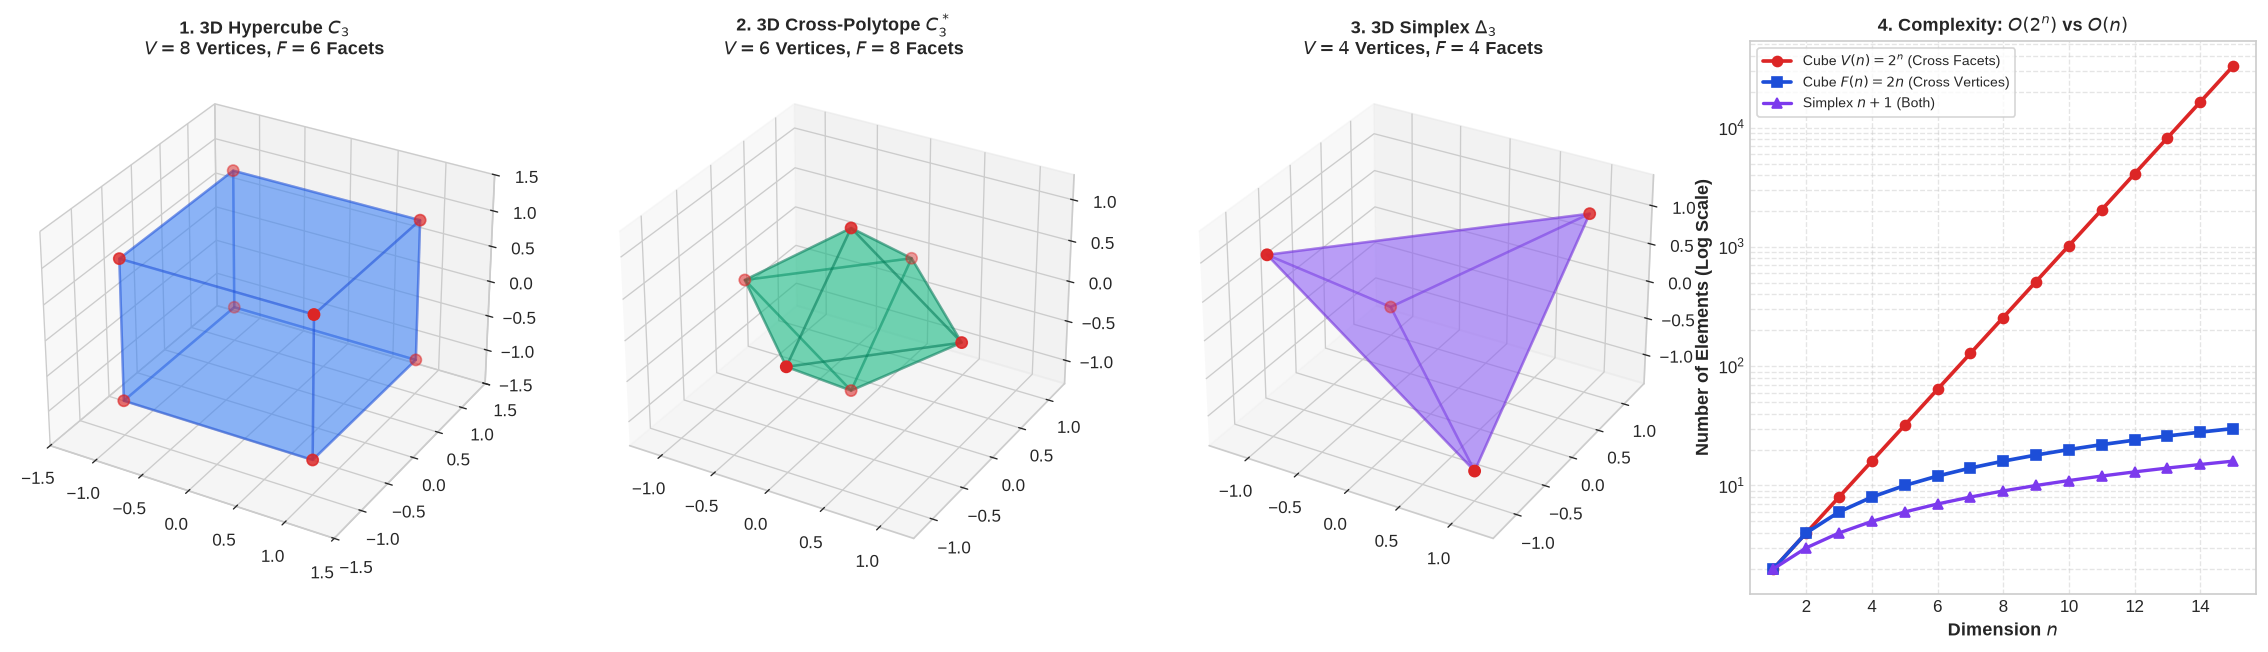

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig = plt.figure(figsize=(19, 5.5), dpi=120)

# -----------------------------------------------------
# 1. 3D Hypercube (8 Vertices, 6 Facets)
# -----------------------------------------------------
ax1 = fig.add_subplot(1, 4, 1, projection='3d')
r = [-1, 1]
cube_verts = np.array([[x, y, z] for x in r for y in r for z in r])
faces = [
    [cube_verts[0], cube_verts[1], cube_verts[3], cube_verts[2]],
    [cube_verts[4], cube_verts[5], cube_verts[7], cube_verts[6]],
    [cube_verts[0], cube_verts[1], cube_verts[5], cube_verts[4]],
    [cube_verts[2], cube_verts[3], cube_verts[7], cube_verts[6]],
    [cube_verts[0], cube_verts[2], cube_verts[6], cube_verts[4]],
    [cube_verts[1], cube_verts[3], cube_verts[7], cube_verts[5]]
]
poly1 = Poly3DCollection(faces, alpha=0.35, edgecolor='#1d4ed8', facecolor='#3b82f6', linewidths=1.5)
ax1.add_collection3d(poly1)
ax1.scatter(cube_verts[:, 0], cube_verts[:, 1], cube_verts[:, 2], color='#dc2626', s=45)
ax1.set_title(r'1. 3D Hypercube $C_3$' + '\n' + r'$V=8$ Vertices, $F=6$ Facets', fontsize=11, fontweight='bold')
ax1.set_xlim([-1.5, 1.5]); ax1.set_ylim([-1.5, 1.5]); ax1.set_zlim([-1.5, 1.5])

# -----------------------------------------------------
# 2. 3D Cross-Polytope / Octahedron (6 Vertices, 8 Facets)
# -----------------------------------------------------
ax2 = fig.add_subplot(1, 4, 2, projection='3d')
oct_verts = np.array([
    [1, 0, 0], [-1, 0, 0],
    [0, 1, 0], [0, -1, 0],
    [0, 0, 1], [0, 0, -1]
])
oct_faces = [
    [oct_verts[0], oct_verts[2], oct_verts[4]],
    [oct_verts[0], oct_verts[3], oct_verts[4]],
    [oct_verts[1], oct_verts[2], oct_verts[4]],
    [oct_verts[1], oct_verts[3], oct_verts[4]],
    [oct_verts[0], oct_verts[2], oct_verts[5]],
    [oct_verts[0], oct_verts[3], oct_verts[5]],
    [oct_verts[1], oct_verts[2], oct_verts[5]],
    [oct_verts[1], oct_verts[3], oct_verts[5]]
]
poly2 = Poly3DCollection(oct_faces, alpha=0.35, edgecolor='#047857', facecolor='#10b981', linewidths=1.5)
ax2.add_collection3d(poly2)
ax2.scatter(oct_verts[:, 0], oct_verts[:, 1], oct_verts[:, 2], color='#dc2626', s=45)
ax2.set_title(r'2. 3D Cross-Polytope $C_3^*$' + '\n' + r'$V=6$ Vertices, $F=8$ Facets', fontsize=11, fontweight='bold')
ax2.set_xlim([-1.3, 1.3]); ax2.set_ylim([-1.3, 1.3]); ax2.set_zlim([-1.3, 1.3])

# -----------------------------------------------------
# 3. 3D Simplex / Tetrahedron (4 Vertices, 4 Facets)
# -----------------------------------------------------
ax3 = fig.add_subplot(1, 4, 3, projection='3d')
tet_verts = np.array([
    [1, 1, 1], [1, -1, -1],
    [-1, 1, -1], [-1, -1, 1]
])
tet_faces = [
    [tet_verts[0], tet_verts[1], tet_verts[2]],
    [tet_verts[0], tet_verts[1], tet_verts[3]],
    [tet_verts[0], tet_verts[2], tet_verts[3]],
    [tet_verts[1], tet_verts[2], tet_verts[3]]
]
poly3 = Poly3DCollection(tet_faces, alpha=0.35, edgecolor='#6d28d9', facecolor='#8b5cf6', linewidths=1.5)
ax3.add_collection3d(poly3)
ax3.scatter(tet_verts[:, 0], tet_verts[:, 1], tet_verts[:, 2], color='#dc2626', s=45)
ax3.set_title(r'3. 3D Simplex $\Delta_3$' + '\n' + r'$V=4$ Vertices, $F=4$ Facets', fontsize=11, fontweight='bold')
ax3.set_xlim([-1.4, 1.4]); ax3.set_ylim([-1.4, 1.4]); ax3.set_zlim([-1.4, 1.4])

# -----------------------------------------------------
# 4. Representation Complexity Growth (2D Semilog)
# -----------------------------------------------------
ax4 = fig.add_subplot(1, 4, 4)
n_vals = np.arange(1, 16)
v_cube = 2.0**n_vals
f_cube = 2.0 * n_vals
v_cross = 2.0 * n_vals
f_cross = 2.0**n_vals
simplex = n_vals + 1.0

ax4.semilogy(n_vals, v_cube, 'o-', color='#dc2626', lw=2.2, label=r'Cube $V(n) = 2^n$ (Cross Facets)')
ax4.semilogy(n_vals, f_cube, 's-', color='#1d4ed8', lw=2.2, label=r'Cube $F(n) = 2n$ (Cross Vertices)')
ax4.semilogy(n_vals, simplex, '^-', color='#7c3aed', lw=2.0, label=r'Simplex $n+1$ (Both)')

ax4.set_xlabel(r'Dimension $n$', fontsize=11, fontweight='bold')
ax4.set_ylabel(r'Number of Elements (Log Scale)', fontsize=11, fontweight='bold')
ax4.set_title(r'4. Complexity: $O(2^n)$ vs $O(n)$', fontsize=11, fontweight='bold')
ax4.legend(loc='upper left', fontsize=8.5, frameon=True)
ax4.grid(True, which='both', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()